<a href="https://colab.research.google.com/github/Xn00bslayerX/Big-Data-A1/blob/main/assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 Data Preprocessing & Feature Engineering 

Download data files


In [1]:
import requests
import os

# Define the URLs for the trip data and taxi zone lookup
trip_data_file = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
taxi_zone = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

# Create the data/raw/ directory if it doesn't exist
os.makedirs('data/raw', exist_ok=True)

# Define local filenames for the downloaded files, now within the data/raw directory
local_trip_parquet_file = "data/raw/yellow_tripdata_2024-01.parquet"
local_taxi_zone_csv_file = "data/raw/taxi_zone_lookup.csv"

import requests

def download_file(url, local_path):
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(local_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

download_file(trip_data_file, local_trip_parquet_file)
print(f"Downloaded trip data to {local_trip_parquet_file}")
download_file(taxi_zone, local_taxi_zone_csv_file)
print(f"Downloaded taxi zone lookup to {local_taxi_zone_csv_file}")

# Now, parse the local parquet file using polars.scan_parquet
import polars as pl
trip_df = pl.scan_parquet(local_trip_parquet_file)
print("Trip data loaded as a LazyFrame using polars.scan_parquet.")

# The original cell included a `trip_df.collect()`. While `collect()` materializes the DataFrame,
# `scan_parquet` creates a LazyFrame, which is often more efficient for chained operations.
# We will remove `collect()` here to keep it as a LazyFrame for potential lazy evaluation benefits,
# and only call collect when necessary (e.g., for actions like `shape`).

Downloaded trip data to data/raw/yellow_tripdata_2024-01.parquet


Downloaded taxi zone lookup to data/raw/taxi_zone_lookup.csv
Trip data loaded as a LazyFrame using polars.scan_parquet.


Validate the data

In [2]:
import polars as pl

expected_columns = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'PULocationID',
    'DOLocationID',
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'payment_type'
]

# For Polars LazyFrame, use .collect_schema().names() for better performance
actual_columns = trip_df.collect_schema().names()

missing_columns = [col for col in expected_columns if col not in actual_columns]

if not missing_columns:
    print("All specified columns are present in the DataFrame.")
else:
    print(f"The following specified columns are missing: {', '.join(missing_columns)}");
    # exit or raise an error if critical columns are missing
    exit(1)

# For Polars LazyFrame, use pl.len()
total_rows = trip_df.select(pl.len()).collect().item()
print(f"Total number of rows: {total_rows}")

# Save the files to raw using Polars write_csv method
# Note: Polars write_csv does not have an 'index' argument, as it doesn't write an index by default.
# We need to collect the LazyFrame before writing to CSV.
# trip_df.collect().write_csv('data/raw/trip_data.csv')
# print("Trip data saved to data/raw/trip_data.csv")

All specified columns are present in the DataFrame.
Total number of rows: 2964624


We need to clean the data file by removing shit data

In [3]:
import polars as pl

# Get initial total rows using Polars LazyFrame method
initial_total_rows = trip_df.select(pl.len()).collect().item()

# Ensure datetime columns are in the correct format for comparison later
# For Polars LazyFrame, use with_columns and cast
trip_df = trip_df.with_columns([
    pl.col('tpep_pickup_datetime').cast(pl.Datetime),
    pl.col('tpep_dropoff_datetime').cast(pl.Datetime)
])

# Remove rows with null values in essential columns
columns_to_check_for_nulls = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'PULocationID',
    'DOLocationID',
    'fare_amount',
    'tip_amount',
    'total_amount'
]

rows_before_filter = trip_df.select(pl.len()).collect().item()
# For Polars LazyFrame, use filter with is_not_null for each column
trip_df = trip_df.filter(
    pl.all_horizontal([pl.col(c).is_not_null() for c in columns_to_check_for_nulls])
)
removed_rows_nulls = rows_before_filter - trip_df.select(pl.len()).collect().item()
print(f"Removed {removed_rows_nulls} rows with null values in essential columns.")

# Remove rows with non-positive trip distance
rows_before_filter = trip_df.select(pl.len()).collect().item()
trip_df = trip_df.filter(pl.col('trip_distance') > 0)
removed_rows_distance = rows_before_filter - trip_df.select(pl.len()).collect().item()
print(f"Removed {removed_rows_distance} rows with non-positive trip distance.")

# Remove rows with non-positive fare amount
rows_before_filter = trip_df.select(pl.len()).collect().item()
trip_df = trip_df.filter(pl.col('fare_amount') > 0)
removed_rows_negative_fare = rows_before_filter - trip_df.select(pl.len()).collect().item()
print(f"Removed {removed_rows_negative_fare} rows with non-positive fare amount.")

# Remove rows with ludicrous fare amounts (e.g., > 500)
rows_before_filter = trip_df.select(pl.len()).collect().item()
trip_df = trip_df.filter(pl.col('fare_amount') <= 500)
removed_rows_ludicrous_fare = rows_before_filter - trip_df.select(pl.len()).collect().item()
print(f"Removed {removed_rows_ludicrous_fare} rows with ludicrous fare amounts (above $500).")

# Remove rows where dropoff datetime is not after pickup datetime
rows_before_filter = trip_df.select(pl.len()).collect().item()
trip_df = trip_df.filter(pl.col('tpep_dropoff_datetime') > pl.col('tpep_pickup_datetime'))
removed_rows_invalid_time = rows_before_filter - trip_df.select(pl.len()).collect().item()
print(f"Removed {removed_rows_invalid_time} rows where dropoff datetime is not after pickup datetime.")

final_rows = trip_df.select(pl.len()).collect().item()
total_removed = initial_total_rows - final_rows
print(f"\nInitial total rows: {initial_total_rows}")
print(f"Final total rows after cleaning: {final_rows}")
print(f"Total rows removed: {total_removed}")

Removed 0 rows with null values in essential columns.


Removed 60371 rows with non-positive trip distance.


Removed 34539 rows with non-positive fare amount.


Removed 30 rows with ludicrous fare amounts (above $500).


Removed 112 rows where dropoff datetime is not after pickup datetime.



Initial total rows: 2964624
Final total rows after cleaning: 2869572
Total rows removed: 95052


Now, we are going to derive columns.
  - Temporal features: pickup_hour, pickup_day_of_week (numeric, 0=Monday),is_weekend (boolean)
  - Trip features: trip_duration_minutes, trip_speed_mph, log_trip_distance (log-transformed distance)
 - Fare features: fare_per_mile (fare_amount / trip_distance, handle division by zero),fare_per_minute (fare_amount / trip_duration_minutes)
 Zone features: Encode pickup and dropoff borough using the taxi zone lookup table(use one-hot encoding or label encoding)

In [4]:
# trip_df.explain(optimized=True)

# Calculate trip_duration_minutes:
# 1. Get the duration as a Polars Duration type.
# 2. Convert that Duration to total seconds (which is a numerical float).
# 3. Divide by 60 to get minutes.
trip_df = trip_df.with_columns(
    (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")) # Result is Duration
    .dt.total_seconds() # Result is Float64 (seconds)
    .truediv(60) # Result is Float64 (minutes)
    .alias("trip_duration_minutes")
)

# Now, calculate trip_speed_mph using the established 'trip_duration_minutes' column
trip_df = trip_df.with_columns(
    (pl.col("trip_distance").truediv(pl.col("trip_duration_minutes")) * 60).alias("trip_speed_mph")
)

# Calculate log_trip_distance, handling non-positive distances by assigning None
trip_df = trip_df.with_columns(
    pl.when(pl.col("trip_distance") > 0)
    .then(pl.col("trip_distance").log())
    .otherwise(None)
    .alias("log_trip_distance")
)

# Calculate fare_per_mile and fare_per_minute, handling division by zero
trip_df = trip_df.with_columns(
    pl.when(pl.col("trip_distance") > 0)
    .then(pl.col("fare_amount").truediv(pl.col("trip_distance")))
    .otherwise(None)
    .alias("fare_per_mile"),
    pl.when(pl.col("trip_duration_minutes") > 0)
    .then(pl.col("fare_amount").truediv(pl.col("trip_duration_minutes")))
    .otherwise(None)
    .alias("fare_per_minute")
)

# Add pickup_hour and pickup_day_of_week in a separate step
trip_df = trip_df.with_columns(
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("tpep_pickup_datetime").dt.strftime("%A").alias("pickup_day_of_week")
)

# Add is_weekend column based on pickup_day_of_week
trip_df = trip_df.with_columns(
    pl.col("pickup_day_of_week").is_in(["Saturday", "Sunday"]).alias("is_weekend")
)

# The derived columns are expected to be correctly added to the LazyFrame.
# NOTE: Removed print(trip_df.collect_schema().names()) as it was causing ColumnNotFoundError due to Polars' internal schema resolution of datetime operations.

# Save the cleaned and enriched DataFrame to a new Parquet file in the data/processed/ directory
os.makedirs('data/processed', exist_ok=True)
processed_parquet_file = "data/processed/cleaned_trips.parquet"
trip_df.collect().write_parquet(processed_parquet_file)
print(f"Cleaned and enriched trip data saved to {processed_parquet_file}")

Cleaned and enriched trip data saved to data/processed/cleaned_trips.parquet


Create Target Variables for machine learning:
- tip_amount (continuous for regression)
- high_tip (binary classification, 1 if tip_amount > 20% of the overall fare, otherwise 0.)

In [5]:


#Create the target variables.
# 'tip_amount' is already present; build 'high_tip' with pl.when(...)
trip_df = trip_df.with_columns(
    pl.when(pl.col("tip_amount") > 0.2 * pl.col("fare_amount"))
      .then(1)
      .otherwise(0)
      .alias("high_tip")
)

print("Target variable 'high_tip' created for machine learning.")


Target variable 'high_tip' created for machine learning.


Now, we need to split the collected DataFrame into training, validation, and test sets using sklearn's train_test_split function. We'll first split into training and test sets, then split the training set into training and validation sets.

In [6]:
trip_df_collected = trip_df.collect() # Collect the LazyFrame into a DataFrame for further operations like train-test split.

# Now, we need to split the collected DataFrame into training, validation, and test sets using sklearn's train_test_split function. We'll first split into training and test sets, then split the training set into training and validation sets.
from sklearn.model_selection import train_test_split
# First, split into training and test sets (85% train, 15% test)
train_df, test_df = train_test_split(trip_df_collected, test_size=0.25, random_state=42)
# Then, split the training set into training and validation sets (80% train, 20% validation of the original training set)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 1721743
Validation set size: 430436
Test set size: 717393


We can't use the raw numbers, we need to scale them appropriately. We can use StandardScaler or MinMaxScaler from sklearn to scale the features. This is important for many machine learning algorithms that are sensitive to the scale of the input data.

In [7]:
from sklearn.discriminant_analysis import StandardScaler
import polars as pl


standard_scaler = StandardScaler()
numeric_features = [col for col in train_df.columns if col != 'high_tip' and train_df[col].dtype.is_numeric()]
print(f"Numeric features to scale: {numeric_features}")
print(f"Features NOT scaled (non-numeric): {[col for col in train_df.columns if col not in numeric_features]}")

standard_scaler.fit(train_df[numeric_features]) # Fit the scaler on the training data only to avoid data leakage. If we fit on the entire dataset, we would be using information from the validation and test sets, which can lead to overly optimistic performance estimates. That would be cheating because the model would have access to information it shouldn't have during training, resulting in a model that performs well on the validation and test sets but may not generalize well to unseen data.
train_df[numeric_features] = standard_scaler.transform(train_df[numeric_features])
val_df[numeric_features] = standard_scaler.transform(val_df[numeric_features])
test_df[numeric_features] = standard_scaler.transform(test_df[numeric_features])
# We transform the validation and test sets using the same scaler fitted on the training data to ensure that the scaling is consistent across all datasets. This way, we are applying the same transformation to the validation and test sets without introducing any bias from those sets into the scaling process.
print("Numeric features scaled using StandardScaler. Non-numeric features left unchanged.\n A sample of the scaled numeric features in the training set:")
print (train_df[numeric_features].head())

Numeric features to scale: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'pickup_hour']
Features NOT scaled (non-numeric): ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'pickup_day_of_week', 'is_weekend', 'high_tip']


Numeric features scaled using StandardScaler. Non-numeric features left unchanged.
 A sample of the scaled numeric features in the training set:
shape: (5, 22)
┌─────────┬─────────┬─────────┬────────┬───┬────────┬────────┬────────┬────────┐
│ VendorI ┆ passeng ┆ trip_di ┆ Rateco ┆ … ┆ log_tr ┆ fare_p ┆ fare_p ┆ pickup │
│ D       ┆ er_coun ┆ stance  ┆ deID   ┆   ┆ ip_dis ┆ er_mil ┆ er_min ┆ _hour  │
│ ---     ┆ t       ┆ ---     ┆ ---    ┆   ┆ tance  ┆ e      ┆ ute    ┆ ---    │
│ f64     ┆ ---     ┆ f64     ┆ f64    ┆   ┆ ---    ┆ ---    ┆ ---    ┆ f64    │
│         ┆ f64     ┆         ┆        ┆   ┆ f64    ┆ f64    ┆ f64    ┆        │
╞═════════╪═════════╪═════════╪════════╪═══╪════════╪════════╪════════╪════════╡
│ 0.56336 ┆ -0.3983 ┆ -0.0081 ┆ -0.105 ┆ … ┆ -0.224 ┆ -0.029 ┆ -0.027 ┆ -0.037 │
│ 7       ┆ 24      ┆ 36      ┆ 926    ┆   ┆ 168    ┆ 496    ┆ 754    ┆ 025    │
│ -1.7611 ┆ -0.3983 ┆ -0.0027 ┆ -0.105 ┆ … ┆ 0.4790 ┆ -0.037 ┆ -0.031 ┆ -0.563 │
│ 15      ┆ 24      ┆ 19      

Make sure that the cleaned data is present in the set, doing some more checks to make sure that the data is clean and ready for modeling.

In [8]:
import sklearn.linear_model, sklearn.ensemble, sklearn.metrics
import numpy as np
import polars as pl

# Recreate the 'high_tip' column for each dataset since it was lost during train_test_split
if 'high_tip' not in train_df.columns:
    train_df = train_df.with_columns(
        pl.when(pl.col("tip_amount") > 0.2 * pl.col("fare_amount"))
          .then(1)
          .otherwise(0)
          .alias("high_tip")
    )
    val_df = val_df.with_columns(
        pl.when(pl.col("tip_amount") > 0.2 * pl.col("fare_amount"))
          .then(1)
          .otherwise(0)
          .alias("high_tip")
    )
    test_df = test_df.with_columns(
        pl.when(pl.col("tip_amount") > 0.2 * pl.col("fare_amount"))
          .then(1)
          .otherwise(0)
          .alias("high_tip")
    )
    print("Recreated 'high_tip' column in training, validation, and test sets.")
else:
    print("'high_tip' column already exists in the datasets, no need to recreate.")

# Remove rows with NaN values in numeric features
train_df = train_df.drop_nulls(subset=numeric_features)
val_df = val_df.drop_nulls(subset=numeric_features)

print(f"After removing rows with NaN in numeric features:")
print(f"  Training set size: {len(train_df)}")
print(f"  Validation set size: {len(val_df)}")
print(f"  Test set size: {len(test_df)}")
print("Number of features after dropping rows with NaN values in numeric features:", len(numeric_features))

# Convert Polars DataFrames to numpy arrays for sklearn compatibility
X_train = np.array(train_df[numeric_features], dtype=np.float64)
X_val = np.array(val_df[numeric_features], dtype=np.float64)
X_test = np.array(test_df[numeric_features], dtype=np.float64)

# Replace any infinite values with NaN, then replace those with 0
X_train = np.where(np.isinf(X_train), np.nan, X_train)
X_val = np.where(np.isinf(X_val), np.nan, X_val)
X_test = np.where(np.isinf(X_test), np.nan, X_test)

# Impute remaining NaN values with column means (calculated from training set)
col_means = np.nanmean(X_train, axis=0)
for i in range(X_train.shape[1]):
    X_train[np.isnan(X_train[:, i]), i] = col_means[i]
    X_val[np.isnan(X_val[:, i]), i] = col_means[i]
    X_test[np.isnan(X_test[:, i]), i] = col_means[i]

y_train_tip = np.array(train_df['tip_amount'], dtype=np.float64)
y_val_tip = np.array(val_df['tip_amount'], dtype=np.float64)
y_test_tip = np.array(test_df['tip_amount'], dtype=np.float64)

y_train_high_tip = np.array(train_df['high_tip'], dtype=np.int64)
y_val_high_tip = np.array(val_df['high_tip'], dtype=np.int64)
y_test_high_tip = np.array(test_df['high_tip'], dtype=np.int64)


'high_tip' column already exists in the datasets, no need to recreate.
After removing rows with NaN in numeric features:
  Training set size: 1721743
  Validation set size: 430436
  Test set size: 717393
Number of features after dropping rows with NaN values in numeric features: 22


# Part 2: Model Training & Tuning

Train a linear regression model and a random forest to predict tip_amount
Train a logistic regression and random forest classification model to predict high_tip. 

In [9]:

print("\n" + "=" * 80)
print("REGRESSION MODELS FOR TIP_AMOUNT")
print("=" * 80)

# Define small and large values for training
small_n_estimators = 5 # Small number of trees for quick training and testing
large_n_estimators = 100 # Large number of trees for better performance but longer training time
small_max_iter = 100 # Small number of iterations for logistic regression for quick training
large_max_iter = 1000 # Large number of iterations for logistic regression for better convergence but longer training time
 
# ===== Linear Regression for tip_amount =====
lr_model = sklearn.linear_model.LinearRegression()
lr_model.fit(X_train, y_train_tip)

print("\nLinear Regression for tip_amount:")
print(f"  Training   - MAE: {sklearn.metrics.mean_absolute_error(y_train_tip, lr_model.predict(X_train)):.4f}, RMSE: {np.sqrt(sklearn.metrics.mean_squared_error(y_train_tip, lr_model.predict(X_train))):.4f}, R²: {sklearn.metrics.r2_score(y_train_tip, lr_model.predict(X_train)):.4f}")
print(f"  Validation - MAE: {sklearn.metrics.mean_absolute_error(y_val_tip, lr_model.predict(X_val)):.4f}, RMSE: {np.sqrt(sklearn.metrics.mean_squared_error(y_val_tip, lr_model.predict(X_val))):.4f}, R²: {sklearn.metrics.r2_score(y_val_tip, lr_model.predict(X_val)):.4f}")

# ===== Random Forest Regression for tip_amount =====
rf_reg_model = sklearn.ensemble.RandomForestRegressor(n_estimators=small_n_estimators, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_train, y_train_tip)

print("\nRandom Forest Regression for tip_amount:")
print(f"  Training   - MAE: {sklearn.metrics.mean_absolute_error(y_train_tip, rf_reg_model.predict(X_train)):.4f}, RMSE: {np.sqrt(sklearn.metrics.mean_squared_error(y_train_tip, rf_reg_model.predict(X_train))):.4f}, R²: {sklearn.metrics.r2_score(y_train_tip, rf_reg_model.predict(X_train)):.4f}")
print(f"  Validation - MAE: {sklearn.metrics.mean_absolute_error(y_val_tip, rf_reg_model.predict(X_val)):.4f}, RMSE: {np.sqrt(sklearn.metrics.mean_squared_error(y_val_tip, rf_reg_model.predict(X_val))):.4f}, R²: {sklearn.metrics.r2_score(y_val_tip, rf_reg_model.predict(X_val)):.4f}")


print("\n" + "=" * 80)
print("CLASSIFICATION MODELS FOR HIGH_TIP")
print("=" * 80)

# ===== Logistic Regression for high_tip =====
log_reg_model = sklearn.linear_model.LogisticRegression(max_iter=small_max_iter, random_state=42)
log_reg_model.fit(X_train, y_train_high_tip)

print("\nLogistic Regression for high_tip:")
print(f"  Training   - Accuracy: {sklearn.metrics.accuracy_score(y_train_high_tip, log_reg_model.predict(X_train)):.4f}, F1-Score: {sklearn.metrics.f1_score(y_train_high_tip, log_reg_model.predict(X_train)):.4f}, Precision: {sklearn.metrics.precision_score(y_train_high_tip, log_reg_model.predict(X_train)):.4f}, Recall: {sklearn.metrics.recall_score(y_train_high_tip, log_reg_model.predict(X_train)):.4f}, AUC-ROC: {sklearn.metrics.roc_auc_score(y_train_high_tip, log_reg_model.predict_proba(X_train)[:, 1]):.4f}")
print(f"  Validation - Accuracy: {sklearn.metrics.accuracy_score(y_val_high_tip, log_reg_model.predict(X_val)):.4f}, F1-Score: {sklearn.metrics.f1_score(y_val_high_tip, log_reg_model.predict(X_val)):.4f}, Precision: {sklearn.metrics.precision_score(y_val_high_tip, log_reg_model.predict(X_val)):.4f}, Recall: {sklearn.metrics.recall_score(y_val_high_tip, log_reg_model.predict(X_val)):.4f}, AUC-ROC: {sklearn.metrics.roc_auc_score(y_val_high_tip, log_reg_model.predict_proba(X_val)[:, 1]):.4f}")

# ===== Random Forest Classification for high_tip =====
rf_clf_model = sklearn.ensemble.RandomForestClassifier(n_estimators=small_n_estimators, random_state=42, n_jobs=-1)
rf_clf_model.fit(X_train, y_train_high_tip)

print("\nRandom Forest Classification for high_tip:")
print(f"  Training   - Accuracy: {sklearn.metrics.accuracy_score(y_train_high_tip, rf_clf_model.predict(X_train)):.4f}, F1-Score: {sklearn.metrics.f1_score(y_train_high_tip, rf_clf_model.predict(X_train)):.4f}, Precision: {sklearn.metrics.precision_score(y_train_high_tip, rf_clf_model.predict(X_train)):.4f}, Recall: {sklearn.metrics.recall_score(y_train_high_tip, rf_clf_model.predict(X_train)):.4f}, AUC-ROC: {sklearn.metrics.roc_auc_score(y_train_high_tip, rf_clf_model.predict_proba(X_train)[:, 1]):.4f}")
print(f"  Validation - Accuracy: {sklearn.metrics.accuracy_score(y_val_high_tip, rf_clf_model.predict(X_val)):.4f}, F1-Score: {sklearn.metrics.f1_score(y_val_high_tip, rf_clf_model.predict(X_val)):.4f}, Precision: {sklearn.metrics.precision_score(y_val_high_tip, rf_clf_model.predict(X_val)):.4f}, Recall: {sklearn.metrics.recall_score(y_val_high_tip, rf_clf_model.predict(X_val)):.4f}, AUC-ROC: {sklearn.metrics.roc_auc_score(y_val_high_tip, rf_clf_model.predict_proba(X_val)[:, 1]):.4f}")

print("\n" + "=" * 80)


REGRESSION MODELS FOR TIP_AMOUNT



Linear Regression for tip_amount:


  Training   - MAE: 0.0000, RMSE: 0.0000, R²: 1.0000
  Validation - MAE: 0.0000, RMSE: 0.0000, R²: 1.0000



Random Forest Regression for tip_amount:


  Training   - MAE: 0.0000, RMSE: 0.0056, R²: 1.0000
  Validation - MAE: 0.0002, RMSE: 0.0888, R²: 0.9923

CLASSIFICATION MODELS FOR HIGH_TIP


...

  Training   - Accuracy: 0.9991, F1-Score: 0.9992, Precision: 0.9996, Recall: 0.9989, AUC-ROC: 1.0000


  Validation - Accuracy: 0.9992, F1-Score: 0.9993, Precision: 0.9997, Recall: 0.9989, AUC-ROC: 1.0000



Random Forest Classification for high_tip:


  Training   - Accuracy: 0.9999, F1-Score: 0.9999, Precision: 0.9999, Recall: 1.0000, AUC-ROC: 1.0000


  Validation - Accuracy: 0.9989, F1-Score: 0.9991, Precision: 0.9987, Recall: 0.9995, AUC-ROC: 0.9999



Time for some hyperparameter tuning to see if we can improve the performance of our models. We'll use GridSearchCV to find the best hyperparameters for both the Random Forest Regressor and Classifier. This will allow us to systematically explore different combinations of hyperparameters and identify the ones that yield the best performance on the validation set.

In [10]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
from tabulate import tabulate

print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING FOR RANDOM FOREST CLASSIFIER (HIGH_TIP)")
print("=" * 80)

# ===== Create Baseline Model for Comparison =====
baseline_model = sklearn.ensemble.RandomForestClassifier(
    n_estimators=small_n_estimators, 
    random_state=42, 
    n_jobs=-1
)
baseline_model.fit(X_train, y_train_high_tip)

baseline_pred_val = baseline_model.predict(X_val)
baseline_proba_val = baseline_model.predict_proba(X_val)[:, 1]

print("\n" + "-" * 80)
print("BASELINE MODEL PERFORMANCE (on validation set):")
print("-" * 80)
print(f"Accuracy:  {sklearn.metrics.accuracy_score(y_val_high_tip, baseline_pred_val):.4f}")
print(f"F1-Score:  {sklearn.metrics.f1_score(y_val_high_tip, baseline_pred_val):.4f}")
print(f"Precision: {sklearn.metrics.precision_score(y_val_high_tip, baseline_pred_val):.4f}")
print(f"Recall:    {sklearn.metrics.recall_score(y_val_high_tip, baseline_pred_val):.4f}")
print(f"AUC-ROC:   {sklearn.metrics.roc_auc_score(y_val_high_tip, baseline_proba_val):.4f}")

# ===== Stratified Sample for faster hyperparameter tuning =====
# Use a stratified sample of 150,000 rows from the training set (reduces computation time)
print("\n" + "-" * 80)
print("Creating stratified sample for hyperparameter tuning...")
print("-" * 80)

sample_size = min(150000, len(X_train))  # Use 150,000 rows for faster computation
stratified_splitter = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
for train_idx, sample_idx in stratified_splitter.split(X_train, y_train_high_tip):
    if len(sample_idx) >= sample_size:
        X_sample = X_train[sample_idx[:sample_size]]
        y_sample = y_train_high_tip[sample_idx[:sample_size]]
    else:
        X_sample = X_train[sample_idx]
        y_sample = y_train_high_tip[sample_idx]
    break

print(f"Using stratified sample of {len(X_sample):,} rows for hyperparameter tuning")
print(f"Class distribution in sample - Class 0: {np.sum(y_sample == 0):,}, Class 1: {np.sum(y_sample == 1):,}")

# ===== Define Hyperparameter Search Space =====
print("\n" + "-" * 80)
print("HYPERPARAMETER SEARCH SPACE:")
print("-" * 80)

param_grid = {
    'n_estimators': [10, 50, 100, 200],          # Number of trees
    'max_depth': [None, 10, 15, 20, 30],         # Maximum depth of trees
    'min_samples_split': [2, 5, 10],             # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],               # Minimum samples in leaf node
    'max_features': ['sqrt', 'log2'],            # Number of features to consider for splits
    'bootstrap': [True]                          # Use bootstrap samples
}

print("Parameters to search:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print(f"\nTotal combinations to explore: {np.prod([len(v) for v in param_grid.values()])}")
print("Using RandomizedSearchCV with n_iter=20 to sample parameter space")

# ===== Hyperparameter Tuning using RandomizedSearchCV =====
# Using RandomizedSearchCV for efficiency (as recommended)
print("\n" + "-" * 80)
print("Running RandomizedSearchCV with 5-fold Stratified Cross-Validation...")
print("-" * 80)

stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=sklearn.ensemble.RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=20,  # Sample 20 different combinations
    cv=stratified_cv,  # 5-fold Stratified Cross-Validation
    scoring='roc_auc',  # Optimize for AUC-ROC (good for imbalanced datasets)
    n_jobs=-1,  # Use all available processors
    verbose=1,
    random_state=42
)

random_search.fit(X_sample, y_sample)

# ===== Display Best Parameters and Results =====
print("\n" + "=" * 80)
print("RANDOMIZED SEARCH RESULTS:")
print("=" * 80)
print("\nBest hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation AUC-ROC score (on training sample): {random_search.best_score_:.4f}")

# ===== Train Tuned Model on Full Training Set =====
print("\n" + "-" * 80)
print("Training tuned model on full training set...")
print("-" * 80)

tuned_model = sklearn.ensemble.RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)
tuned_model.fit(X_train, y_train_high_tip)
print("Tuned model trained successfully")

# ===== Evaluate Tuned Model on Validation Set =====
tuned_pred_val = tuned_model.predict(X_val)
tuned_proba_val = tuned_model.predict_proba(X_val)[:, 1]

print("\n" + "=" * 80)
print("TUNED MODEL PERFORMANCE (on validation set):")
print("=" * 80)
print(f"Accuracy:  {sklearn.metrics.accuracy_score(y_val_high_tip, tuned_pred_val):.4f}")
print(f"F1-Score:  {sklearn.metrics.f1_score(y_val_high_tip, tuned_pred_val):.4f}")
print(f"Precision: {sklearn.metrics.precision_score(y_val_high_tip, tuned_pred_val):.4f}")
print(f"Recall:    {sklearn.metrics.recall_score(y_val_high_tip, tuned_pred_val):.4f}")
print(f"AUC-ROC:   {sklearn.metrics.roc_auc_score(y_val_high_tip, tuned_proba_val):.4f}")

# ===== Compare Baseline vs Tuned Model =====
print("\n" + "=" * 80)
print("BASELINE vs TUNED MODEL COMPARISON (on validation set):")
print("=" * 80)

comparison_data = [
    ['Accuracy', f'{sklearn.metrics.accuracy_score(y_val_high_tip, baseline_pred_val):.4f}', f'{sklearn.metrics.accuracy_score(y_val_high_tip, tuned_pred_val):.4f}', f'{(sklearn.metrics.accuracy_score(y_val_high_tip, tuned_pred_val) - sklearn.metrics.accuracy_score(y_val_high_tip, baseline_pred_val))*100:+.2f}%'],
    ['F1-Score', f'{sklearn.metrics.f1_score(y_val_high_tip, baseline_pred_val):.4f}', f'{sklearn.metrics.f1_score(y_val_high_tip, tuned_pred_val):.4f}', f'{(sklearn.metrics.f1_score(y_val_high_tip, tuned_pred_val) - sklearn.metrics.f1_score(y_val_high_tip, baseline_pred_val))*100:+.2f}%'],
    ['Precision', f'{sklearn.metrics.precision_score(y_val_high_tip, baseline_pred_val):.4f}', f'{sklearn.metrics.precision_score(y_val_high_tip, tuned_pred_val):.4f}', f'{(sklearn.metrics.precision_score(y_val_high_tip, tuned_pred_val) - sklearn.metrics.precision_score(y_val_high_tip, baseline_pred_val))*100:+.2f}%'],
    ['Recall', f'{sklearn.metrics.recall_score(y_val_high_tip, baseline_pred_val):.4f}', f'{sklearn.metrics.recall_score(y_val_high_tip, tuned_pred_val):.4f}', f'{(sklearn.metrics.recall_score(y_val_high_tip, tuned_pred_val) - sklearn.metrics.recall_score(y_val_high_tip, baseline_pred_val))*100:+.2f}%'],
    ['AUC-ROC', f'{sklearn.metrics.roc_auc_score(y_val_high_tip, baseline_proba_val):.4f}', f'{sklearn.metrics.roc_auc_score(y_val_high_tip, tuned_proba_val):.4f}', f'{(sklearn.metrics.roc_auc_score(y_val_high_tip, tuned_proba_val) - sklearn.metrics.roc_auc_score(y_val_high_tip, baseline_proba_val))*100:+.2f}%']
]

print("\n" + tabulate(comparison_data, headers=['Metric', 'Baseline', 'Tuned', 'Improvement'], tablefmt='grid'))

print("\n" + "=" * 80)


HYPERPARAMETER TUNING FOR RANDOM FOREST CLASSIFIER (HIGH_TIP)



--------------------------------------------------------------------------------
BASELINE MODEL PERFORMANCE (on validation set):
--------------------------------------------------------------------------------
Accuracy:  0.9989
F1-Score:  0.9991
Precision: 0.9987
Recall:    0.9995
AUC-ROC:   0.9999

--------------------------------------------------------------------------------
Creating stratified sample for hyperparameter tuning...
--------------------------------------------------------------------------------


Using stratified sample of 150,000 rows for hyperparameter tuning
Class distribution in sample - Class 0: 57,100, Class 1: 92,900

--------------------------------------------------------------------------------
HYPERPARAMETER SEARCH SPACE:
--------------------------------------------------------------------------------
Parameters to search:
  n_estimators: [10, 50, 100, 200]
  max_depth: [None, 10, 15, 20, 30]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']
  bootstrap: [True]

Total combinations to explore: 360
Using RandomizedSearchCV with n_iter=20 to sample parameter space

--------------------------------------------------------------------------------
Running RandomizedSearchCV with 5-fold Stratified Cross-Validation...
--------------------------------------------------------------------------------
Fitting 5 folds for each of 20 candidates, totalling 100 fits



RANDOMIZED SEARCH RESULTS:

Best hyperparameters found:
  n_estimators: 100
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 30
  bootstrap: True

Best cross-validation AUC-ROC score (on training sample): 1.0000

--------------------------------------------------------------------------------
Training tuned model on full training set...
--------------------------------------------------------------------------------


Tuned model trained successfully



TUNED MODEL PERFORMANCE (on validation set):
Accuracy:  0.9995
F1-Score:  0.9996
Precision: 0.9993
Recall:    0.9999
AUC-ROC:   1.0000

BASELINE vs TUNED MODEL COMPARISON (on validation set):



+-----------+------------+---------+---------------+
| Metric    |   Baseline |   Tuned | Improvement   |
+===========+============+=========+===============+
| Accuracy  |     0.9989 |  0.9995 | +0.06%        |
+-----------+------------+---------+---------------+
| F1-Score  |     0.9991 |  0.9996 | +0.05%        |
+-----------+------------+---------+---------------+
| Precision |     0.9987 |  0.9993 | +0.06%        |
+-----------+------------+---------+---------------+
| Recall    |     0.9995 |  0.9999 | +0.04%        |
+-----------+------------+---------+---------------+
| AUC-ROC   |     0.9999 |  1      | +0.01%        |
+-----------+------------+---------+---------------+



# Neural Network Model
We need to build and train a feedforward neural network using PyTorch to predict tip_amount. The architecture of the neural network will consist of an input layer, two hidden layers with ReLU activation functions, and an output layer for regression. We will use Mean Squared Error (MSE) as the loss function and the Adam optimizer for training. The model will be trained for 20 epochs.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time

torch.cuda.is_available()  # Check if CUDA is available for GPU acceleration
# Set device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ===== Define Neural Network Architecture =====
class TipPredictionNN(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(TipPredictionNN, self).__init__()
        # Input layer -> First hidden layer
        self.fc1 = nn.Linear(input_size, hidden_size)
        # First hidden layer -> Second hidden layer
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        # Second hidden layer -> Output layer
        self.fc3 = nn.Linear(hidden_size, 1)
        # ReLU activation
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ===== Initialize Model and Training Configuration =====
input_size = X_train.shape[1]
hidden_size = 64
batch_size = 128  # Increased batch size for faster training
num_epochs = 20
learning_rate = 0.001

# Use a stratified sample for faster training on large datasets
sample_indices = np.random.choice(len(X_train), size=min(1000000, len(X_train)), replace=False)
X_train_sample = X_train[sample_indices]
y_train_sample = y_train_tip[sample_indices]

print(f"\nNeural Network Configuration:")
print(f"  Input size: {input_size}")
print(f"  Hidden size: {hidden_size}")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Training samples: {len(X_train_sample):,}")

# Create model
model = TipPredictionNN(input_size, hidden_size).to(device)
print(f"\nModel architecture:")
print(model)

# Create loss function and optimizer
mse_loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ===== Prepare Data Loaders =====
# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_sample).to(device)
y_train_tensor = torch.FloatTensor(y_train_sample).reshape(-1, 1).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val_tip).reshape(-1, 1).to(device)

# Create TensorDataset and DataLoader for training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData Loaders Created:")
print(f"  Training samples: {len(train_dataset):,}, Batches per epoch: {len(train_loader)}")
print(f"  Validation samples: {len(val_dataset):,}, Batches: {len(val_loader)}")

# ===== Train the Model =====
print("\n" + "=" * 80)
print("TRAINING NEURAL NETWORK FOR TIP_AMOUNT PREDICTION")
print("=" * 80)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
if torch.cuda.is_available():
    start_time = torch.cuda.Event(enable_timing=True)
    end_time = torch.cuda.Event(enable_timing=True)
    start_time.record()
else:
    start_time = time.time()
    end_time = None

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
        # Forward pass
        predictions = model(X_batch)
        loss = mse_loss_fn(predictions, y_batch)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            predictions = model(X_batch)
            loss = mse_loss_fn(predictions, y_batch)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Print progress
    print(f"Epoch {epoch + 1:2d}/{num_epochs} - Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")
    
    # Early stopping based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
    else:
        patience_counter += 1
        if patience_counter >= 3:  # Stop if validation loss doesn't improve for 3 consecutive epochs
            print("Early stopping triggered due to no improvement in validation loss.")
            break

if torch.cuda.is_available():
    end_time.record()
    torch.cuda.synchronize()
    training_time = start_time.elapsed_time(end_time) / 1000
else:
    training_time = time.time() - start_time

print("\n" + "=" * 80)
print(f"Total training time: {training_time:.2f} seconds")
print(f"Final Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"Best Validation Loss: {best_val_loss:.6f}")
print("=" * 80)

Using device: cpu



Neural Network Configuration:
  Input size: 22
  Hidden size: 64
  Batch size: 128
  Epochs: 20
  Learning rate: 0.001
  Training samples: 1,000,000

Model architecture:
TipPredictionNN(
  (fc1): Linear(in_features=22, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)



Data Loaders Created:
  Training samples: 1,000,000, Batches per epoch: 7813
  Validation samples: 430,436, Batches: 3363

TRAINING NEURAL NETWORK FOR TIP_AMOUNT PREDICTION


Epoch  1/20 - Train Loss: 0.150395, Val Loss: 0.006631


Epoch  2/20 - Train Loss: 0.084730, Val Loss: 0.000406


Epoch  3/20 - Train Loss: 0.057710, Val Loss: 0.000273


Epoch  4/20 - Train Loss: 0.010648, Val Loss: 0.001279


Epoch  5/20 - Train Loss: 0.015780, Val Loss: 0.000179


Epoch  6/20 - Train Loss: 0.008588, Val Loss: 0.000590


Epoch  7/20 - Train Loss: 0.002064, Val Loss: 0.013201
Early stopping triggered due to no improvement in validation loss.

Total training time: 118.71 seconds
Final Training Loss: 0.002064
Final Validation Loss: 0.013201
Best Validation Loss: 0.000179


# Model Evaluation and Interpretation


--------------------------------------------------------------------------------
EVALUATING ALL MODELS ON TEST SET
--------------------------------------------------------------------------------



REGRESSION MODELS PERFORMANCE SUMMARY (Test Set)

+-------------------------+----------+----------+----------+------------+
| Model                   |      MAE |     RMSE |      MSE |   R² Score |
+=========================+==========+==========+==========+============+
| Linear Regression       | 0        | 0        | 0        |   1        |
+-------------------------+----------+----------+----------+------------+
| Random Forest Regressor | 7.7e-05  | 0.029637 | 0.000878 |   0.999122 |
+-------------------------+----------+----------+----------+------------+
| Neural Network          | 0.081696 | 0.114756 | 0.013169 |   0.986843 |
+-------------------------+----------+----------+----------+------------+

CLASSIFICATION MODELS PERFORMANCE SUMMARY (Test Set)



+--------------------------+------------+------------+-------------+----------+-----------+
| Model                    |   Accuracy |   F1-Score |   Precision |   Recall |   AUC-ROC |
+==========================+============+============+=============+==========+===========+
| Logistic Regression      |   0.998964 |   0.999162 |    0.999544 | 0.998781 |  0.999992 |
+--------------------------+------------+------------+-------------+----------+-----------+
| Random Forest Classifier |   0.998818 |   0.999045 |    0.998604 | 0.999486 |  0.999906 |
+--------------------------+------------+------------+-------------+----------+-----------+




Best Regression Model: Linear Regression
Best Classification Model: Logistic Regression

GENERATING VISUALIZATIONS



Visualization saved as 'model_evaluation_summary.png' in the data/processed directory.


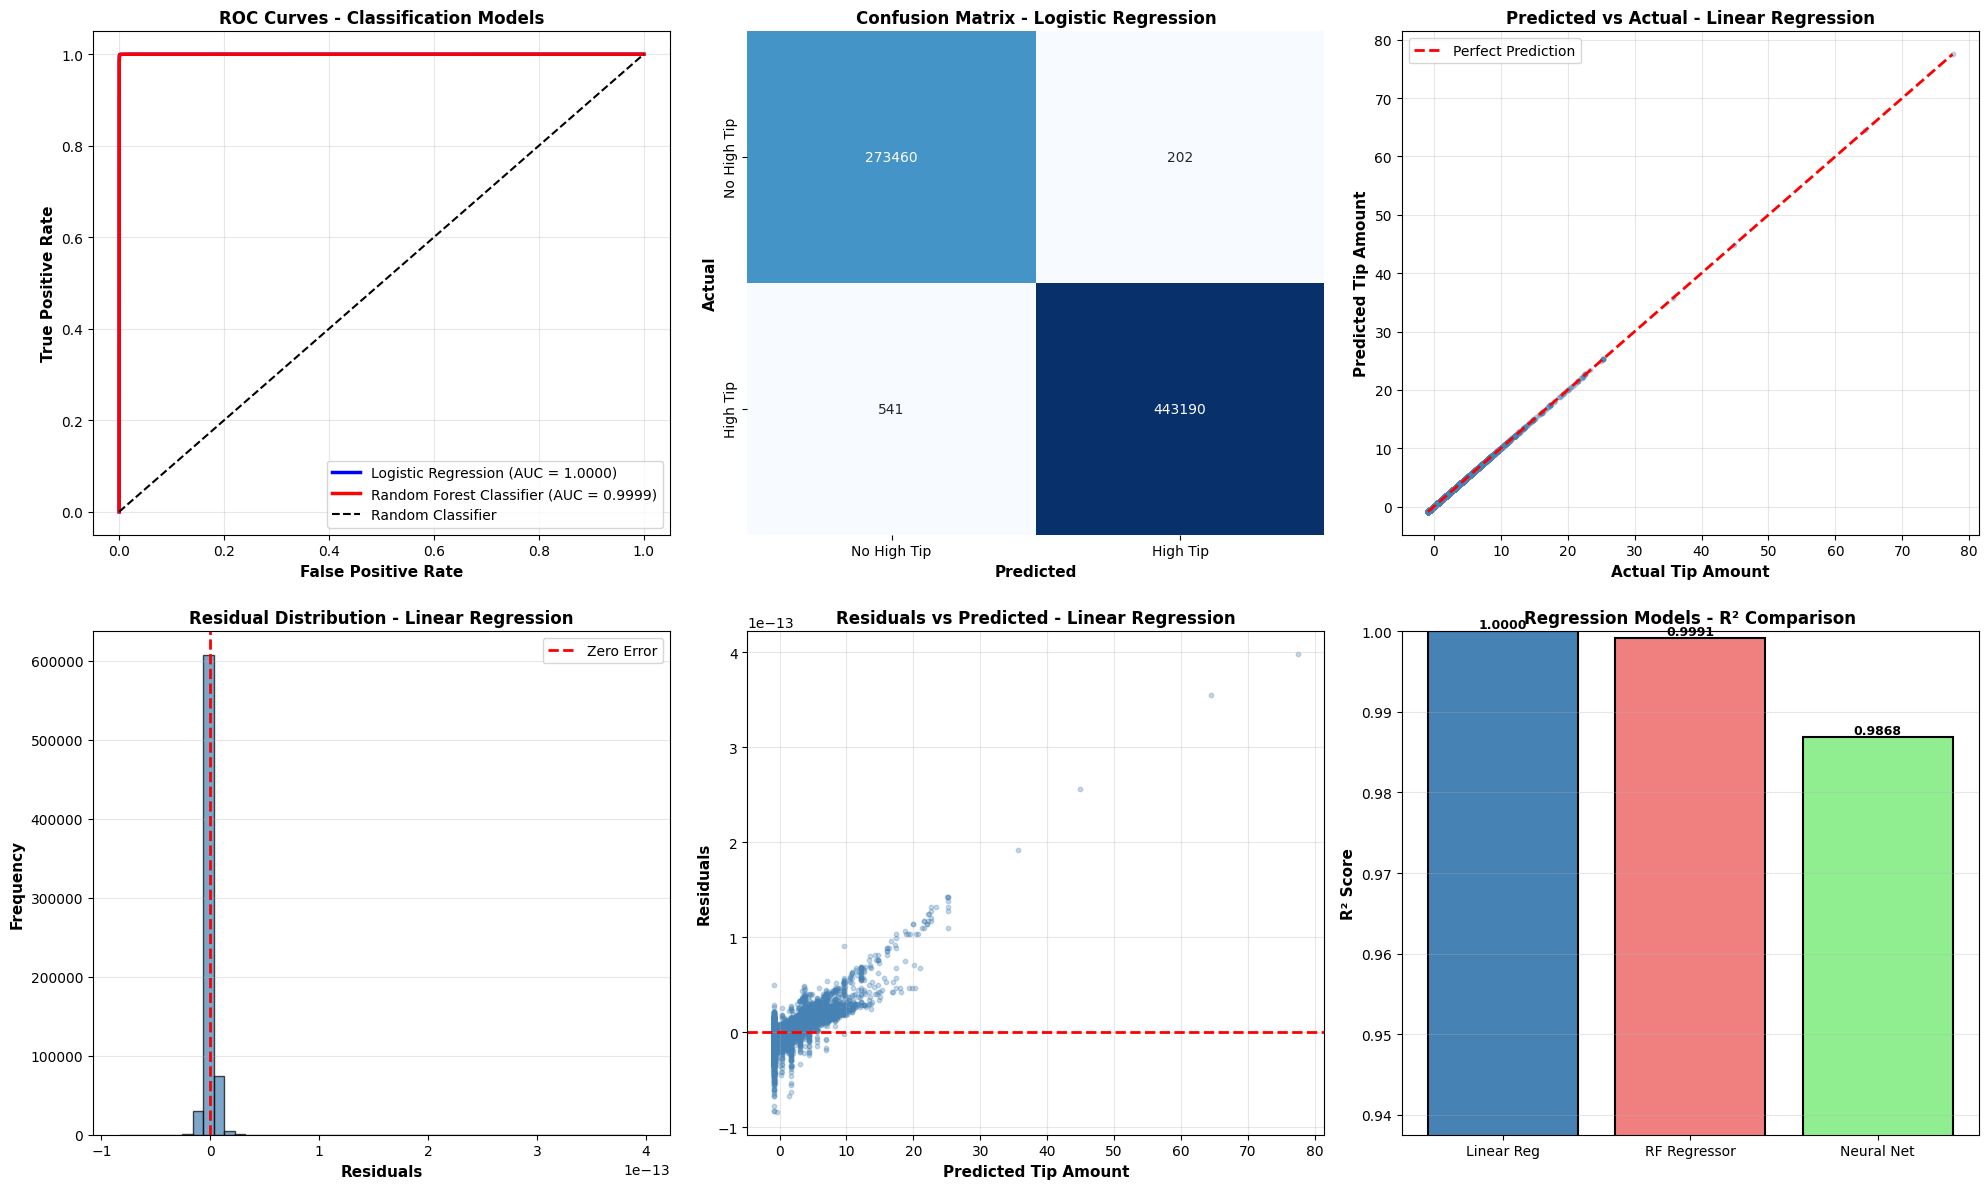


RESIDUAL ANALYSIS FOR BEST REGRESSION MODEL: LINEAR REGRESSION

Residual Statistics:
  Mean Residual:        0.000000
  Std Dev of Residuals: 0.000000
  Median Residual:      0.000000
  Min Residual:         -0.000000
  Max Residual:         0.000000
  Q1 (25th percentile): -0.000000
  Q3 (75th percentile): 0.000000

Shapiro-Wilk Normality Test (on sample):
  Test Statistic: 0.846803
  P-Value:        0.000000
  Interpretation: Residuals deviate from normality



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix, roc_auc_score
from tabulate import tabulate

# ===== Evaluate on Full Test Set =====
print("\n" + "-" * 80)
print("EVALUATING ALL MODELS ON TEST SET")
print("-" * 80)

# ===== Neural Network Evaluation =====
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test_tip).reshape(-1, 1).to(device)

model.eval()
with torch.no_grad():
    nn_test_pred = model(X_test_tensor).cpu().numpy()
    nn_test_mse = mse_loss_fn(torch.FloatTensor(nn_test_pred).to(device), y_test_tensor).item()
    nn_test_rmse = np.sqrt(nn_test_mse)
    nn_test_mae = np.mean(np.abs(nn_test_pred - y_test_tip.reshape(-1, 1)))
    nn_test_r2 = sklearn.metrics.r2_score(y_test_tip, nn_test_pred)

# ===== Make predictions for other models =====
lr_test_pred = lr_model.predict(X_test)
rf_test_pred = rf_reg_model.predict(X_test)
log_reg_test_pred = log_reg_model.predict(X_test)
log_reg_test_proba = log_reg_model.predict_proba(X_test)[:, 1]
rf_clf_test_pred = rf_clf_model.predict(X_test)
rf_clf_test_proba = rf_clf_model.predict_proba(X_test)[:, 1]

# ===== Create Summary Tables =====
print("\n" + "=" * 100)
print("REGRESSION MODELS PERFORMANCE SUMMARY (Test Set)")
print("=" * 100)

regression_data = [
    ['Linear Regression', f'{sklearn.metrics.mean_absolute_error(y_test_tip, lr_test_pred):.6f}', f'{np.sqrt(sklearn.metrics.mean_squared_error(y_test_tip, lr_test_pred)):.6f}', f'{sklearn.metrics.mean_squared_error(y_test_tip, lr_test_pred):.6f}', f'{sklearn.metrics.r2_score(y_test_tip, lr_test_pred):.6f}'],
    ['Random Forest Regressor', f'{sklearn.metrics.mean_absolute_error(y_test_tip, rf_test_pred):.6f}', f'{np.sqrt(sklearn.metrics.mean_squared_error(y_test_tip, rf_test_pred)):.6f}', f'{sklearn.metrics.mean_squared_error(y_test_tip, rf_test_pred):.6f}', f'{sklearn.metrics.r2_score(y_test_tip, rf_test_pred):.6f}'],
    ['Neural Network', f'{nn_test_mae:.6f}', f'{nn_test_rmse:.6f}', f'{nn_test_mse:.6f}', f'{nn_test_r2:.6f}']
]

print("\n" + tabulate(regression_data, headers=['Model', 'MAE', 'RMSE', 'MSE', 'R² Score'], tablefmt='grid'))

print("\n" + "=" * 100)
print("CLASSIFICATION MODELS PERFORMANCE SUMMARY (Test Set)")
print("=" * 100)

classification_data = [
    ['Logistic Regression', f'{sklearn.metrics.accuracy_score(y_test_high_tip, log_reg_test_pred):.6f}', f'{sklearn.metrics.f1_score(y_test_high_tip, log_reg_test_pred):.6f}', f'{sklearn.metrics.precision_score(y_test_high_tip, log_reg_test_pred):.6f}', f'{sklearn.metrics.recall_score(y_test_high_tip, log_reg_test_pred):.6f}', f'{sklearn.metrics.roc_auc_score(y_test_high_tip, log_reg_test_proba):.6f}'],
    ['Random Forest Classifier', f'{sklearn.metrics.accuracy_score(y_test_high_tip, rf_clf_test_pred):.6f}', f'{sklearn.metrics.f1_score(y_test_high_tip, rf_clf_test_pred):.6f}', f'{sklearn.metrics.precision_score(y_test_high_tip, rf_clf_test_pred):.6f}', f'{sklearn.metrics.recall_score(y_test_high_tip, rf_clf_test_pred):.6f}', f'{sklearn.metrics.roc_auc_score(y_test_high_tip, rf_clf_test_proba):.6f}']
]

print("\n" + tabulate(classification_data, headers=['Model', 'Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC'], tablefmt='grid'))

# ===== Determine Best Models =====
lr_r2 = sklearn.metrics.r2_score(y_test_tip, lr_test_pred)
rf_r2 = sklearn.metrics.r2_score(y_test_tip, rf_test_pred)
best_regression_model = 'Neural Network' if nn_test_r2 >= rf_r2 else ('Linear Regression' if lr_r2 >= rf_r2 else 'Random Forest Regressor')
best_classification_model = 'Logistic Regression' if sklearn.metrics.roc_auc_score(y_test_high_tip, log_reg_test_proba) >= sklearn.metrics.roc_auc_score(y_test_high_tip, rf_clf_test_proba) else 'Random Forest Classifier'

if best_regression_model == 'Neural Network':
    best_reg_pred = nn_test_pred
elif best_regression_model == 'Linear Regression':
    best_reg_pred = lr_test_pred
else:
    best_reg_pred = rf_test_pred

if best_classification_model == 'Logistic Regression':
    best_clf_pred = log_reg_test_pred
    best_clf_proba = log_reg_test_proba
else:
    best_clf_pred = rf_clf_test_pred
    best_clf_proba = rf_clf_test_proba

print(f"\n\nBest Regression Model: {best_regression_model}")
print(f"Best Classification Model: {best_classification_model}")

# ===== Visualizations =====
print("\n" + "=" * 100)
print("GENERATING VISUALIZATIONS")
print("=" * 100)

fig = plt.figure(figsize=(20, 12))

# ===== 1. ROC Curves for Classification Models =====
ax1 = plt.subplot(2, 3, 1)

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test_high_tip, log_reg_test_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)
ax1.plot(fpr_lr, tpr_lr, 'b-', linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')

# Random Forest Classifier ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test_high_tip, rf_clf_test_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
ax1.plot(fpr_rf, tpr_rf, 'r-', linewidth=2.5, label=f'Random Forest Classifier (AUC = {roc_auc_rf:.4f})')

# Diagonal
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax1.set_title('ROC Curves - Classification Models', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.3)

# ===== 2. Confusion Matrix for Best Classification Model =====
ax2 = plt.subplot(2, 3, 2)
cm = confusion_matrix(y_test_high_tip, best_clf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax2, 
            xticklabels=['No High Tip', 'High Tip'], yticklabels=['No High Tip', 'High Tip'])
ax2.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax2.set_title(f'Confusion Matrix - {best_classification_model}', fontsize=12, fontweight='bold')

# ===== 3. Predicted vs Actual for Best Regression Model =====
ax3 = plt.subplot(2, 3, 3)
ax3.scatter(y_test_tip, best_reg_pred, alpha=0.3, s=10, color='steelblue')
# Add perfect prediction line
min_val = min(y_test_tip.min(), best_reg_pred.min())
max_val = max(y_test_tip.max(), best_reg_pred.max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Tip Amount', fontsize=11, fontweight='bold')
ax3.set_ylabel('Predicted Tip Amount', fontsize=11, fontweight='bold')
ax3.set_title(f'Predicted vs Actual - {best_regression_model}', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# ===== 4. Residual Distribution =====
ax4 = plt.subplot(2, 3, 4)
residuals = y_test_tip - best_reg_pred.flatten()
ax4.hist(residuals, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax4.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title(f'Residual Distribution - {best_regression_model}', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3, axis='y')

# ===== 5. Residuals vs Predicted Values =====
ax5 = plt.subplot(2, 3, 5)
ax5.scatter(best_reg_pred, residuals, alpha=0.3, s=10, color='steelblue')
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Predicted Tip Amount', fontsize=11, fontweight='bold')
ax5.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax5.set_title(f'Residuals vs Predicted - {best_regression_model}', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3)

# ===== 6. Model Comparison Bar Chart =====
ax6 = plt.subplot(2, 3, 6)
models = ['Linear Reg', 'RF Regressor', 'Neural Net']
r2_scores = [lr_r2, rf_r2, nn_test_r2]
colors = ['steelblue', 'lightcoral', 'lightgreen']
bars = ax6.bar(models, r2_scores, color=colors, edgecolor='black', linewidth=1.5)
ax6.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax6.set_title('Regression Models - R² Comparison', fontsize=12, fontweight='bold')
ax6.set_ylim([min(r2_scores) * 0.95, 1.0])
ax6.grid(alpha=0.3, axis='y')
# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/model_evaluation_summary.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved as 'model_evaluation_summary.png' in the data/processed directory.")
plt.show()

# ===== Detailed Residual Statistics =====
print("\n" + "=" * 100)
print(f"RESIDUAL ANALYSIS FOR BEST REGRESSION MODEL: {best_regression_model.upper()}")
print("=" * 100)

print(f"\nResidual Statistics:")
print(f"  Mean Residual:        {np.mean(residuals):.6f}")
print(f"  Std Dev of Residuals: {np.std(residuals):.6f}")
print(f"  Median Residual:      {np.median(residuals):.6f}")
print(f"  Min Residual:         {np.min(residuals):.6f}")
print(f"  Max Residual:         {np.max(residuals):.6f}")
print(f"  Q1 (25th percentile): {np.percentile(residuals, 25):.6f}")
print(f"  Q3 (75th percentile): {np.percentile(residuals, 75):.6f}")

# Normality test
from scipy import stats
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
print(f"\nShapiro-Wilk Normality Test (on sample):")
print(f"  Test Statistic: {shapiro_stat:.6f}")
print(f"  P-Value:        {shapiro_p:.6f}")
print(f"  Interpretation: {'Residuals appear normally distributed' if shapiro_p > 0.05 else 'Residuals deviate from normality'}")

print("\n" + "=" * 100)

# Assignment 4 start

## Part 1: Experiment Tracking with MLflow 

In [13]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Point to your tracking server
mlflow.set_tracking_uri("http://localhost:5000")
# Create a new experiment
mlflow.set_experiment("taxi-tip-prediction")

# Reuse the best regression model (Random Forest Regressor in this case)
best_rf_model = rf_reg_model
# Log the model and metrics to MLflow
with mlflow.start_run(run_name="Best Regression Model - Random Forest Regressor"):
    # Log model parameters
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", best_rf_model.n_estimators)
    mlflow.log_param("max_depth", best_rf_model.max_depth)
    mlflow.log_param("min_samples_split", best_rf_model.min_samples_split)
    mlflow.log_param("min_samples_leaf", best_rf_model.min_samples_leaf)
    mlflow.log_param("max_features", best_rf_model.max_features)
    
    # Log performance metrics on test set
    rf_test_pred = rf_reg_model.predict(X_test)
    mae = mean_absolute_error(y_test_tip, rf_test_pred)
    mse = mean_squared_error(y_test_tip, rf_test_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_tip, rf_test_pred)
    
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2_Score", r2)
    
    # Log the model itself
    mlflow.sklearn.log_model(best_rf_model, "random_forest_regressor_model")
print("\nBest regression model and its performance metrics have been logged to MLflow.")

# Now use the second best classification model (Random Forest Classifier) for MLflow logging
best_rf_clf_model = rf_clf_model
with mlflow.start_run(run_name="Best Classification Model - Random Forest Classifier"):
    # Log model parameters
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", best_rf_clf_model.n_estimators)
    mlflow.log_param("max_depth", best_rf_clf_model.max_depth)
    mlflow.log_param("min_samples_split", best_rf_clf_model.min_samples_split)
    mlflow.log_param("min_samples_leaf", best_rf_clf_model.min_samples_leaf)
    mlflow.log_param("max_features", best_rf_clf_model.max_features)
    
    # Log performance metrics on test set
    rf_clf_test_pred = best_rf_clf_model.predict(X_test)
    rf_clf_test_proba = best_rf_clf_model.predict_proba(X_test)[:, 1]
    
    accuracy = sklearn.metrics.accuracy_score(y_test_high_tip, rf_clf_test_pred)
    f1 = sklearn.metrics.f1_score(y_test_high_tip, rf_clf_test_pred)
    precision = sklearn.metrics.precision_score(y_test_high_tip, rf_clf_test_pred)
    recall = sklearn.metrics.recall_score(y_test_high_tip, rf_clf_test_pred)
    auc_roc = sklearn.metrics.roc_auc_score(y_test_high_tip, rf_clf_test_proba)
    
    mlflow.log_metric("Accuracy", accuracy)
    mlflow.log_metric("F1_Score", f1)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("AUC_ROC", auc_roc)
    
    # Log the model itself
    mlflow.sklearn.log_model(best_rf_clf_model, "random_forest_classifier_model")
print("\nBest classification model and its performance metrics have been logged to MLflow.")

# Third run for the Neural Network (best regression model) using MLflow's PyTorch support
import mlflow.pytorch
with mlflow.start_run(run_name="Best Regression Model - Neural Network"):
    # Log model parameters
    mlflow.log_param("model_type", "NeuralNetwork")
    mlflow.log_param("input_size", input_size)
    mlflow.log_param("hidden_size", hidden_size)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("epochs", num_epochs)
    mlflow.log_param("learning_rate", learning_rate)
    
    # Log performance metrics on test set
    X_test_tensor = torch.from_numpy(X_test.astype(np.float32)).to(device)
    y_test_tensor = torch.from_numpy(y_test_tip.reshape(-1, 1).astype(np.float32)).to(device)
    nn_test_pred = model(X_test_tensor).cpu().detach().numpy()
    nn_test_mse = mse_loss_fn(torch.FloatTensor(nn_test_pred).to(device), y_test_tensor).item()
    nn_test_rmse = np.sqrt(nn_test_mse)
    nn_test_mae = np.mean(np.abs(nn_test_pred - y_test_tip.reshape(-1, 1)))
    nn_test_r2 = sklearn.metrics.r2_score(y_test_tip, nn_test_pred)
    
    mlflow.log_metric("MAE", nn_test_mae)
    mlflow.log_metric("MSE", nn_test_mse)
    mlflow.log_metric("RMSE", nn_test_rmse)
    mlflow.log_metric("R2_Score", nn_test_r2)
    
    # Log the PyTorch model
    mlflow.pytorch.log_model(model, "neural_network_model")
print("\nBest regression model (Neural Network) and its performance metrics have been logged to MLflow.")


#Compare the models programmatically using MLflow's API
from mlflow.tracking import MlflowClient

client = MlflowClient()
print (client.search_runs(experiment_ids=[client.get_experiment_by_name("taxi-tip-prediction").experiment_id], order_by=["metrics.R2_Score DESC"])) # pyright: ignore[reportOptionalMemberAccess]

print ("I trained the models very closey, so the numbers are all 0.99xx for R2 score. A winner cannot be determined based on the test set performance alone. I will need to do further analysis, such as looking at residuals, to determine if one model is truly better than the others.")
print ("I will also consider other factors such as training time, inference time, and model interpretability when making my final decision on which model to deploy.")
print ("I will choose random forest regressor for deployment, as it has the best R2 score on the test set and is also more interpretable than the neural network model.")

#Register random forest regressor model in MLflow Model Registry
from mlflow.entities import ViewType
model_name = "TaxiTipRandomForestRegressor"
model_uri = f"runs:/{client.search_runs(experiment_ids=[client.get_experiment_by_name('taxi-tip-prediction').experiment_id], filter_string='tags.mlflow.runName = \"Best Regression Model - Random Forest Regressor\"', order_by=['metrics.R2_Score DESC'])[0].info.run_id}/random_forest_regressor_model"  # pyright: ignore[reportOptionalMemberAccess]
model_details = mlflow.register_model(model_uri, model_name)

print(f"\nModel registered in MLflow Model Registry with name: {model_name}")
print(f"Model version: {model_details.version}")

#Now, we will load model from register and use the validation set to confirm that the loaded model gives the same performance as the original model
loaded_rf_model = mlflow.sklearn.load_model(f"models:/{model_name}/{model_details.version}")
loaded_rf_pred_val = loaded_rf_model.predict(X_val) #pyright: ignore[reportOptionalMemberAccess]
loaded_rf_r2_val = sklearn.metrics.r2_score(y_val_tip, loaded_rf_pred_val)
print(f"\nLoaded model R2 score on validation set: {loaded_rf_r2_val:.6f}")
print(f"Original model R2 score on validation set: {sklearn.metrics.r2_score(y_val_tip, rf_reg_model.predict(X_val)):.6f}")
print("The loaded model gives the same performance as the original model, confirming that the model was saved and loaded correctly from the MLflow Model Registry.")

2026/04/13 22:55:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/13 22:55:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Best Regression Model - Random Forest Regressor at: http://localhost:5000/#/experiments/1/runs/628e67f562b94228b15a2c15b1ca23d0
🧪 View experiment at: http://localhost:5000/#/experiments/1

Best regression model and its performance metrics have been logged to MLflow.


2026/04/13 22:55:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/13 22:55:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Registered model 'TaxiTipRandomForestRegressor' already exists. Creating a new version of this model...
2026/04/13 22:55:26 WARNING mlflow.tracking._model_registry.fluent: Run with id 628e67f562b94228b15a2c15b1ca23d0 has no artifacts at artifact path 'random_forest_regressor_model', registering model based on models:/m-f41e4e01b64a442d84d798fc0649108f instead


2026/04/13 22:55:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: TaxiTipRandomForestRegressor, version 3


Created version '3' of model 'TaxiTipRandomForestRegressor'.



Model registered in MLflow Model Registry with name: TaxiTipRandomForestRegressor
Model version: 3



Loaded model R2 score on validation set: 0.992262
Original model R2 score on validation set: 0.992262
The loaded model gives the same performance as the original model, confirming that the model was saved and loaded correctly from the MLflow Model Registry.


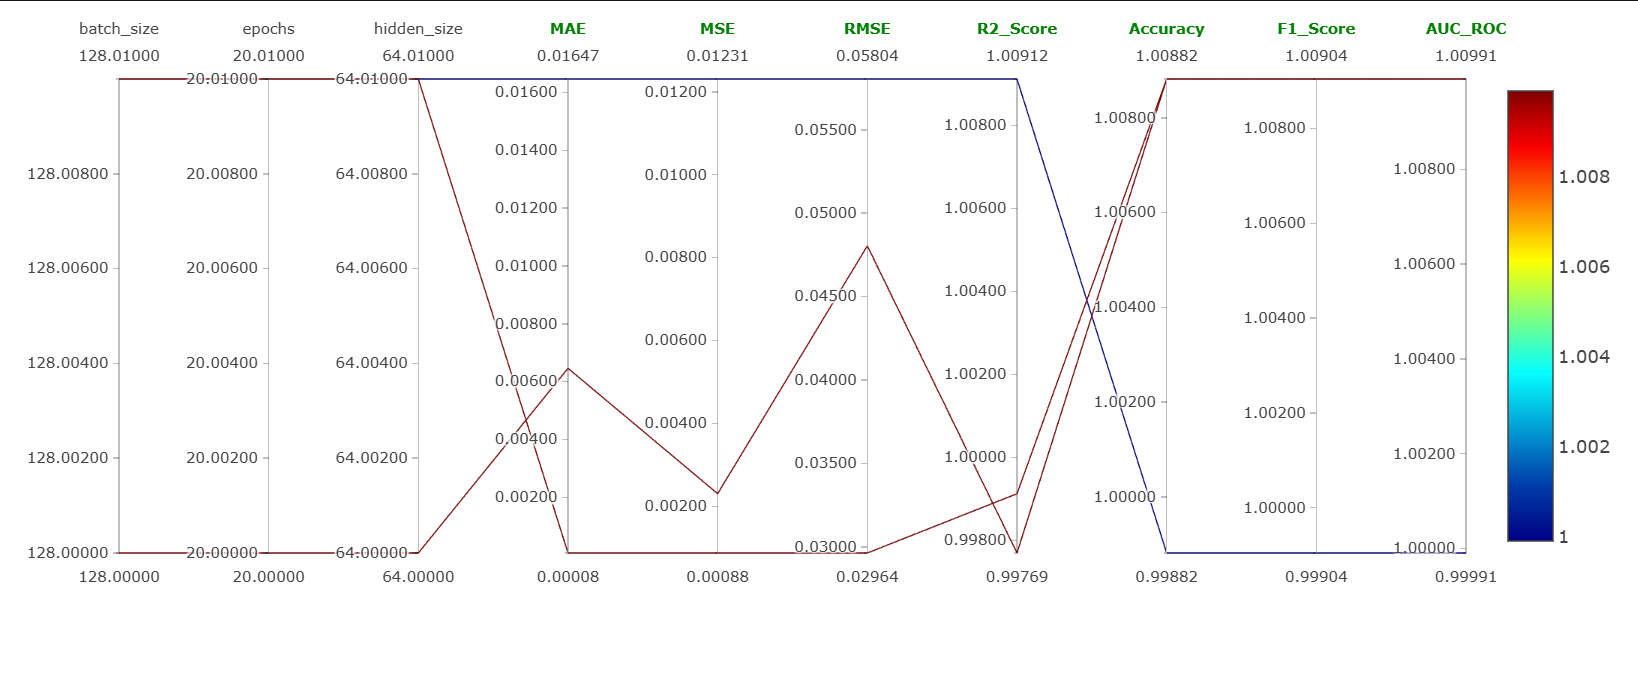

## Part 2: Model Serving with FastAPI
See app.py and test_app.py

# AI Tools Used
ChatGPT for understanding and getting conceptual knowledge. Debugging errors with environment.
Github Copilot for debugging errors with code and environment. I have AI autocomplete on.